# Big Five Personality Test — XGBoost Model Training

**ที่มาของข้อมูล:** Big Five Personality Test (2016–2018) จาก IPIP  
**เป้าหมาย:** ทำนายพฤติกรรมเฉพาะตัว 7 ประการ จากคะแนนบุคลิกภาพ 43 ข้อที่เหลือ

---

### พฤติกรรม 7 ประการที่เป็น Target (drop ออกจาก features):
| Column | คำถาม | ด้าน |
|--------|--------|------|
| CSN6 | I often forget to put things back in their proper place. | Conscientiousness |
| AGR9 | I feel others' emotions. | Agreeableness |
| AGR5 | I am not interested in other people's problems. | Agreeableness |
| EXT4 | I keep in the background. | Extraversion |
| EST7 | I change my mood a lot. | Neuroticism |
| OPN3 | I have a vivid imagination. | Openness |
| OPN10 | I am full of ideas. | Openness |

## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## 1. Data Loading & Initial Exploration

In [2]:
# โหลดข้อมูล (ปรับ path ตามที่จัดเก็บไว้)
df_raw = pd.read_csv('IPIP-FFM-data-8Nov2018\data-final.csv', sep='\t')
print(f'Raw data shape: {df_raw.shape}')
df_raw.head(3)

Raw data shape: (1015341, 110)


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833


---
## 2. Data Cleaning & Preparation

### 2.1 เลือก 50 columns คำถามบุคลิกภาพ

In [3]:
# กำหนด 50 คอลัมน์คำถาม (ตัดคอลัมน์ metadata ออก)
EXT_cols = [f'EXT{i}' for i in range(1, 11)]
EST_cols = [f'EST{i}' for i in range(1, 11)]
AGR_cols = [f'AGR{i}' for i in range(1, 11)]
CSN_cols = [f'CSN{i}' for i in range(1, 11)]
OPN_cols = [f'OPN{i}' for i in range(1, 11)]

all_question_cols = EXT_cols + EST_cols + AGR_cols + CSN_cols + OPN_cols
print(f'Total question columns: {len(all_question_cols)}')
print(all_question_cols)

df = df_raw[all_question_cols].copy()
print(f'\nSelected data shape: {df.shape}')

Total question columns: 50
['EXT1', 'EXT2', 'EXT3', 'EXT4', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST7', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR5', 'AGR6', 'AGR7', 'AGR8', 'AGR9', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN6', 'CSN7', 'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN3', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9', 'OPN10']

Selected data shape: (1015341, 50)


### 2.2 ตรวจสอบค่าที่หายไป (Missing Values)

In [4]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'No missing values found.')

# ลบแถวที่มีค่า missing
df = df.dropna()
print(f'\nShape after dropping NA: {df.shape}')

Missing values per column:
EXT1     1783
EXT2     1783
EXT3     1783
EXT4     1783
EXT5     1783
EXT6     1783
EXT7     1783
EXT8     1783
EXT9     1783
EXT10    1783
EST1     1783
EST2     1783
EST3     1783
EST4     1783
EST5     1783
EST6     1783
EST7     1783
EST8     1783
EST9     1783
EST10    1783
AGR1     1783
AGR2     1783
AGR3     1783
AGR4     1783
AGR5     1783
AGR6     1783
AGR7     1783
AGR8     1783
AGR9     1783
AGR10    1783
CSN1     1783
CSN2     1783
CSN3     1783
CSN4     1783
CSN5     1783
CSN6     1783
CSN7     1783
CSN8     1783
CSN9     1783
CSN10    1783
OPN1     1783
OPN2     1783
OPN3     1783
OPN4     1783
OPN5     1783
OPN6     1783
OPN7     1783
OPN8     1783
OPN9     1783
OPN10    1783
dtype: int64

Shape after dropping NA: (1013558, 50)


### 2.3 ตรวจสอบและลบค่าผิดปกติ (Outliers / Invalid Values)

คำตอบต้องอยู่ในช่วง 1–5 เท่านั้น (Likert scale)

In [5]:
# ตรวจสอบช่วงของค่า
print('Min values per column:')
print(df.min())
print('\nMax values per column:')
print(df.max())

# กรองเฉพาะแถวที่มีค่าทุก column อยู่ในช่วง 1–5
mask_valid = (df >= 1).all(axis=1) & (df <= 5).all(axis=1)
n_removed = (~mask_valid).sum()
df = df[mask_valid].copy()
df = df.astype(int)

print(f'\nRecords removed (out-of-range): {n_removed}')
print(f'Shape after outlier removal: {df.shape}')

Min values per column:
EXT1     0.0
EXT2     0.0
EXT3     0.0
EXT4     0.0
EXT5     0.0
EXT6     0.0
EXT7     0.0
EXT8     0.0
EXT9     0.0
EXT10    0.0
EST1     0.0
EST2     0.0
EST3     0.0
EST4     0.0
EST5     0.0
EST6     0.0
EST7     0.0
EST8     0.0
EST9     0.0
EST10    0.0
AGR1     0.0
AGR2     0.0
AGR3     0.0
AGR4     0.0
AGR5     0.0
AGR6     0.0
AGR7     0.0
AGR8     0.0
AGR9     0.0
AGR10    0.0
CSN1     0.0
CSN2     0.0
CSN3     0.0
CSN4     0.0
CSN5     0.0
CSN6     0.0
CSN7     0.0
CSN8     0.0
CSN9     0.0
CSN10    0.0
OPN1     0.0
OPN2     0.0
OPN3     0.0
OPN4     0.0
OPN5     0.0
OPN6     0.0
OPN7     0.0
OPN8     0.0
OPN9     0.0
OPN10    0.0
dtype: float64

Max values per column:
EXT1     5.0
EXT2     5.0
EXT3     5.0
EXT4     5.0
EXT5     5.0
EXT6     5.0
EXT7     5.0
EXT8     5.0
EXT9     5.0
EXT10    5.0
EST1     5.0
EST2     5.0
EST3     5.0
EST4     5.0
EST5     5.0
EST6     5.0
EST7     5.0
EST8     5.0
EST9     5.0
EST10    5.0
AGR1     5.0
AGR2     5.0
AG

### 2.4 Data Transformation — Reverse Scoring

คำถามที่มีทิศทางกลับ (reverse-scored) ต้องแปลงด้วย `6 - x`

| ด้าน | Reverse items |
|------|---------------|
| EXT  | EXT2, EXT4, EXT6, EXT8, EXT10 |
| EST  | EST2, EST4 |
| AGR  | AGR1, AGR3, AGR5, AGR7 |
| CSN  | CSN2, CSN4, CSN6, CSN8 |
| OPN  | OPN2, OPN4, OPN6 |

In [6]:
reverse_cols = [
    'EXT2', 'EXT4', 'EXT6', 'EXT8', 'EXT10',
    'EST2', 'EST4',
    'AGR1', 'AGR3', 'AGR5', 'AGR7',
    'CSN2', 'CSN4', 'CSN6', 'CSN8',
    'OPN2', 'OPN4', 'OPN6'
]

df_transformed = df.copy()
df_transformed[reverse_cols] = 6 - df_transformed[reverse_cols]

print(f'Reverse-scored columns ({len(reverse_cols)}): {reverse_cols}')
print('\nSample comparison (EXT2 before vs after):')
compare = pd.DataFrame({
    'EXT2_original': df['EXT2'].head(5).values,
    'EXT2_reversed': df_transformed['EXT2'].head(5).values
})
print(compare)

Reverse-scored columns (18): ['EXT2', 'EXT4', 'EXT6', 'EXT8', 'EXT10', 'EST2', 'EST4', 'AGR1', 'AGR3', 'AGR5', 'AGR7', 'CSN2', 'CSN4', 'CSN6', 'CSN8', 'OPN2', 'OPN4', 'OPN6']

Sample comparison (EXT2 before vs after):
   EXT2_original  EXT2_reversed
0              1              5
1              5              1
2              3              3
3              2              4
4              3              3


### 2.5 สร้าง Target Variables — คะแนนรายด้าน (Mean per trait)

คะแนนบุคลิกภาพแต่ละด้านคำนวณจากค่าเฉลี่ยของ 10 ข้อในด้านนั้น (หลัง reverse scoring)

In [7]:
df_transformed['EXT_score'] = df_transformed[EXT_cols].mean(axis=1)
df_transformed['EST_score'] = df_transformed[EST_cols].mean(axis=1)
df_transformed['AGR_score'] = df_transformed[AGR_cols].mean(axis=1)
df_transformed['CSN_score'] = df_transformed[CSN_cols].mean(axis=1)
df_transformed['OPN_score'] = df_transformed[OPN_cols].mean(axis=1)

trait_scores = ['EXT_score', 'EST_score', 'AGR_score', 'CSN_score', 'OPN_score']
print('Trait score statistics:')
df_transformed[trait_scores].describe().round(3)

Trait score statistics:


,EXT_score,EST_score,AGR_score,CSN_score,OPN_score
count,874434.000,874434.000,874434.000,874434.000,874434.000
mean,2.959,3.067,3.774,3.366,3.899
std,0.910,0.859,0.729,0.737,0.630
min,1.000,1.000,1.000,1.000,1.000
25%,2.300,2.400,3.300,2.900,3.500
50%,3.000,3.100,3.900,3.400,3.900
75%,3.600,3.700,4.300,3.900,4.400
max,5.000,5.000,5.000,5.000,5.000


### 2.6 กำหนด Features & Target (7 พฤติกรรมที่สนใจ)

**Target columns (7 พฤติกรรม):**
- `CSN6` — ลืมวางของเข้าที่เดิม
- `AGR9` — รู้สึกถึงอารมณ์คนอื่น
- `AGR5` — ไม่สนใจปัญหาคนอื่น *(reverse-scored แล้ว = ยิ่งสูง ยิ่งสนใจ)*
- `EXT4` — ชอบอยู่ในพื้นหลัง *(reverse-scored แล้ว = ยิ่งสูง ยิ่งไม่ชอบเด่น)*
- `EST7` — อารมณ์แปรปรวน
- `OPN3` — จินตนาการสูง
- `OPN10` — มีไอเดียในหัวมาก

In [8]:
# Target columns
TARGET_COLS = ['CSN6', 'AGR9', 'AGR5', 'EXT4', 'EST7', 'OPN3', 'OPN10']

TARGET_LABELS = {
    'CSN6':  'ลืมวางของ (CSN6)',
    'AGR9':  'รู้สึกอารมณ์คนอื่น (AGR9)',
    'AGR5':  'สนใจปัญหาคนอื่น (AGR5)',
    'EXT4':  'ชอบอยู่ในพื้นหลัง (EXT4)',
    'EST7':  'อารมณ์แปรปรวน (EST7)',
    'OPN3':  'จินตนาการสูง (OPN3)',
    'OPN10': 'มีไอเดียมาก (OPN10)'
}

# Feature columns = 50 คอลัมน์ ลบ 7 target ออก
FEATURE_COLS = [c for c in all_question_cols if c not in TARGET_COLS]
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Target columns ({len(TARGET_COLS)}): {TARGET_COLS}')

# ใช้ข้อมูลจาก df_transformed (หลัง reverse scoring)
X = df_transformed[FEATURE_COLS].copy()
y = df_transformed[TARGET_COLS].copy()

print(f'\nX shape: {X.shape}')
print(f'y shape: {y.shape}')

Feature columns (43): ['EXT1', 'EXT2', 'EXT3', 'EXT5', 'EXT6', 'EXT7', 'EXT8', 'EXT9', 'EXT10', 'EST1', 'EST2', 'EST3', 'EST4', 'EST5', 'EST6', 'EST8', 'EST9', 'EST10', 'AGR1', 'AGR2', 'AGR3', 'AGR4', 'AGR6', 'AGR7', 'AGR8', 'AGR10', 'CSN1', 'CSN2', 'CSN3', 'CSN4', 'CSN5', 'CSN7', 'CSN8', 'CSN9', 'CSN10', 'OPN1', 'OPN2', 'OPN4', 'OPN5', 'OPN6', 'OPN7', 'OPN8', 'OPN9']
Target columns (7): ['CSN6', 'AGR9', 'AGR5', 'EXT4', 'EST7', 'OPN3', 'OPN10']

X shape: (874434, 43)
y shape: (874434, 7)


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 การกระจายของ Target Variables (7 พฤติกรรม)

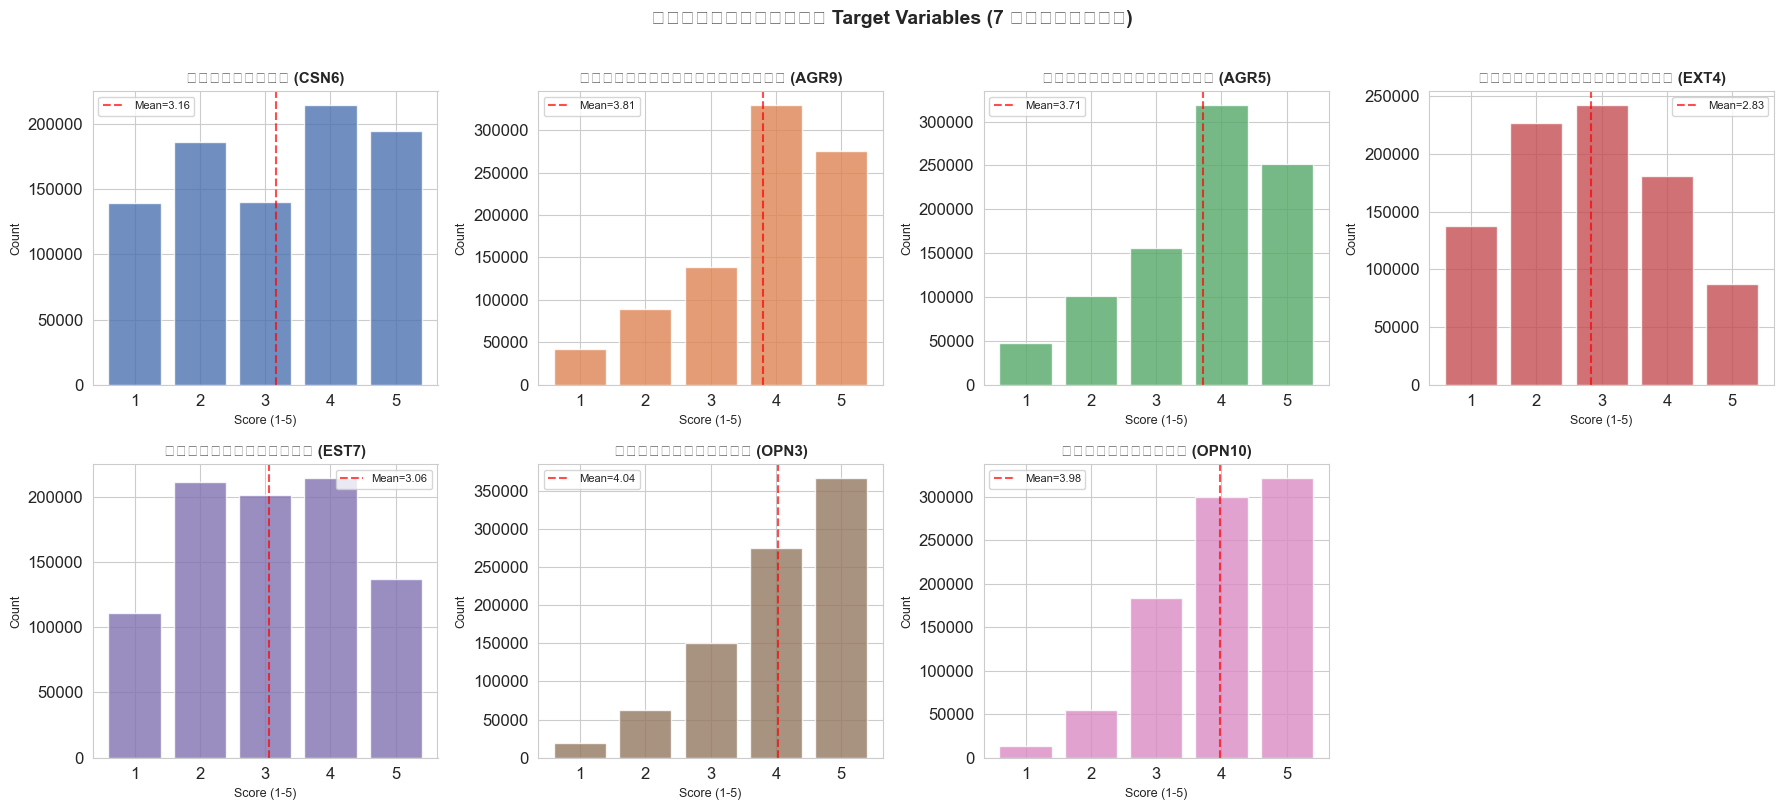

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860', '#DA8BC3']

for i, col in enumerate(TARGET_COLS):
    ax = axes[i]
    value_counts = y[col].value_counts().sort_index()
    ax.bar(value_counts.index, value_counts.values, color=colors[i], alpha=0.8, edgecolor='white')
    ax.set_title(TARGET_LABELS[col], fontsize=11, fontweight='bold')
    ax.set_xlabel('Score (1-5)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_xticks([1, 2, 3, 4, 5])
    mean_val = y[col].mean()
    ax.axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean={mean_val:.2f}')
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
fig.suptitle('การกระจายของ Target Variables (7 พฤติกรรม)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 3.2 Correlation ระหว่าง Target Variables

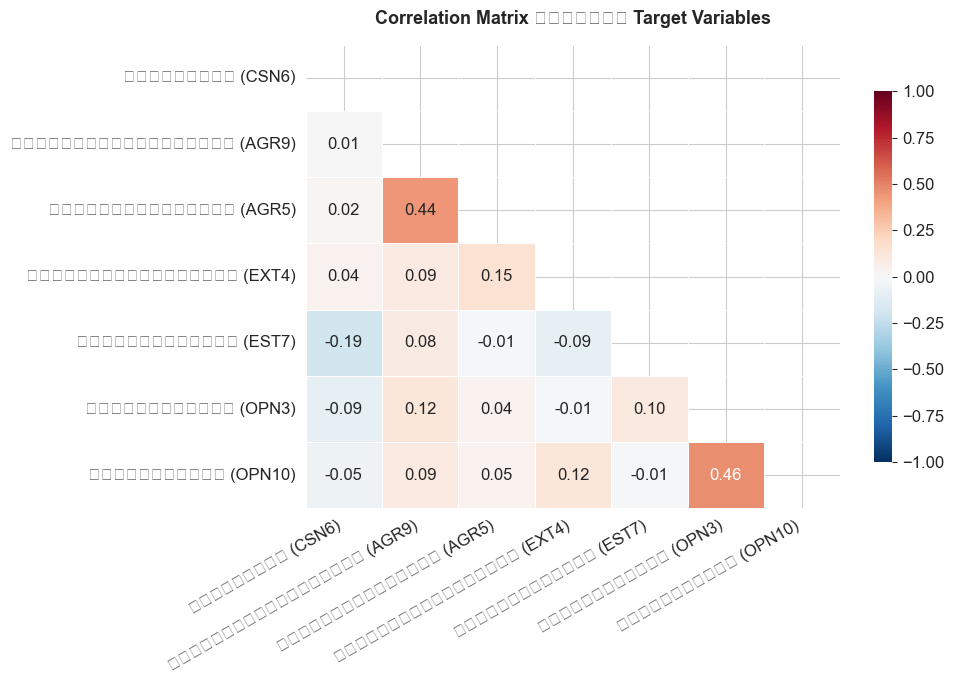

In [10]:
target_corr = y.corr()
target_corr.index = [TARGET_LABELS[c] for c in TARGET_COLS]
target_corr.columns = [TARGET_LABELS[c] for c in TARGET_COLS]

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(target_corr, dtype=bool))
sns.heatmap(target_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix ระหว่าง Target Variables', fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.3 การกระจายของคะแนนรายด้าน Big Five

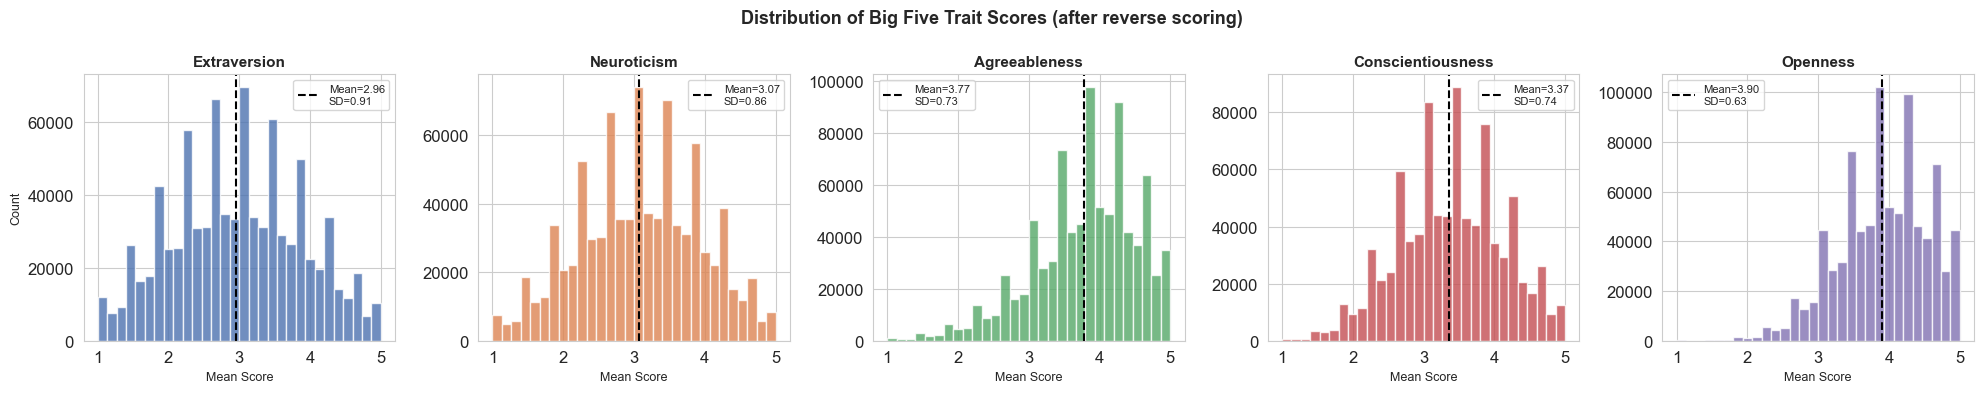

In [11]:
trait_labels = {
    'EXT_score': 'Extraversion',
    'EST_score': 'Neuroticism',
    'AGR_score': 'Agreeableness',
    'CSN_score': 'Conscientiousness',
    'OPN_score': 'Openness'
}
trait_colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (col, label) in enumerate(trait_labels.items()):
    ax = axes[i]
    data = df_transformed[col]
    ax.hist(data, bins=30, color=trait_colors[i], alpha=0.8, edgecolor='white')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean={data.mean():.2f}\nSD={data.std():.2f}')
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Mean Score', fontsize=9)
    ax.set_ylabel('Count' if i == 0 else '', fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle('Distribution of Big Five Trait Scores (after reverse scoring)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Correlation ระหว่าง Features และ Target แต่ละตัว

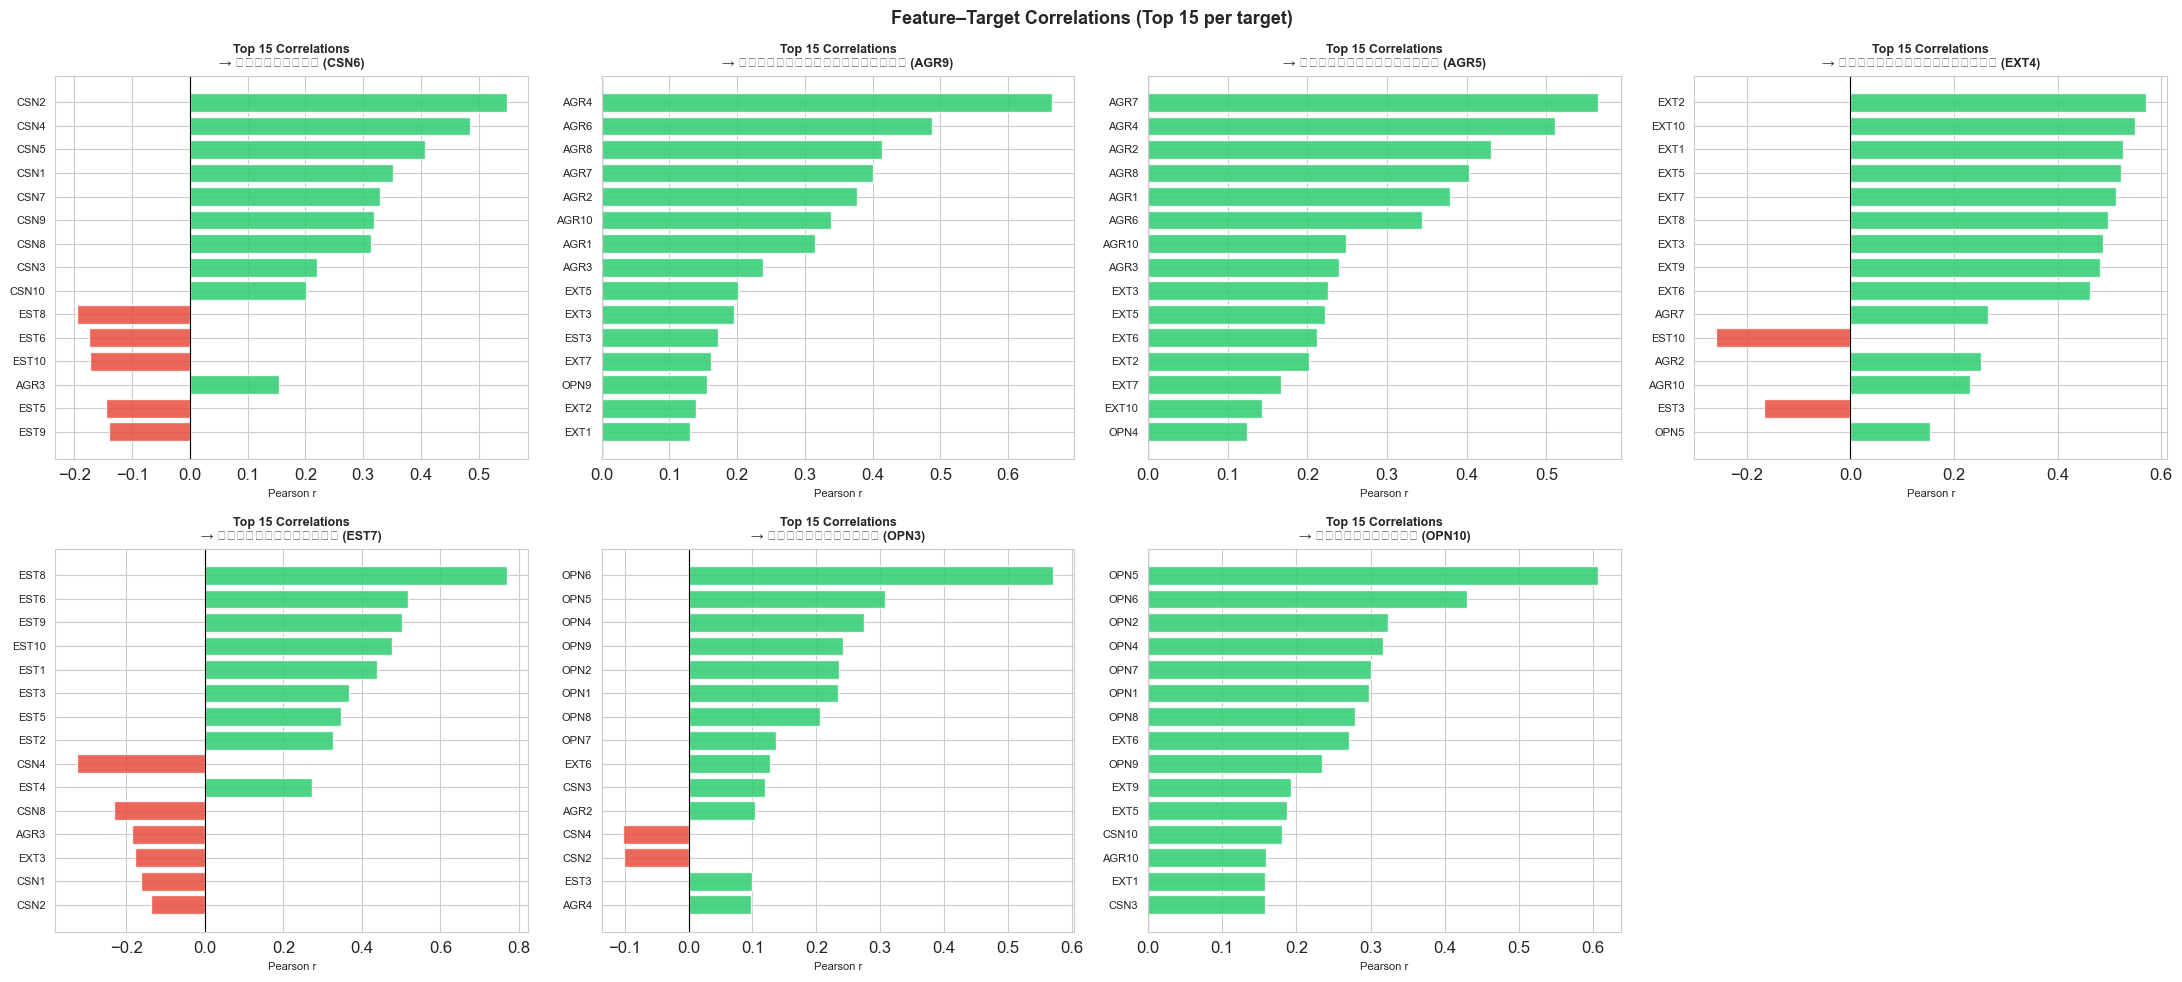

In [12]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    corr_vals = X.corrwith(y[target]).sort_values(key=abs, ascending=False).head(15)
    ax = axes[i]
    bar_colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in corr_vals.values]
    ax.barh(corr_vals.index[::-1], corr_vals.values[::-1], color=bar_colors[::-1], alpha=0.85)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Top 15 Correlations\n→ {TARGET_LABELS[target]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Pearson r', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('Feature–Target Correlations (Top 15 per target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.5 Pairplot ของ Target Variables (กลุ่มตัวอย่าง 2,000 แถว)

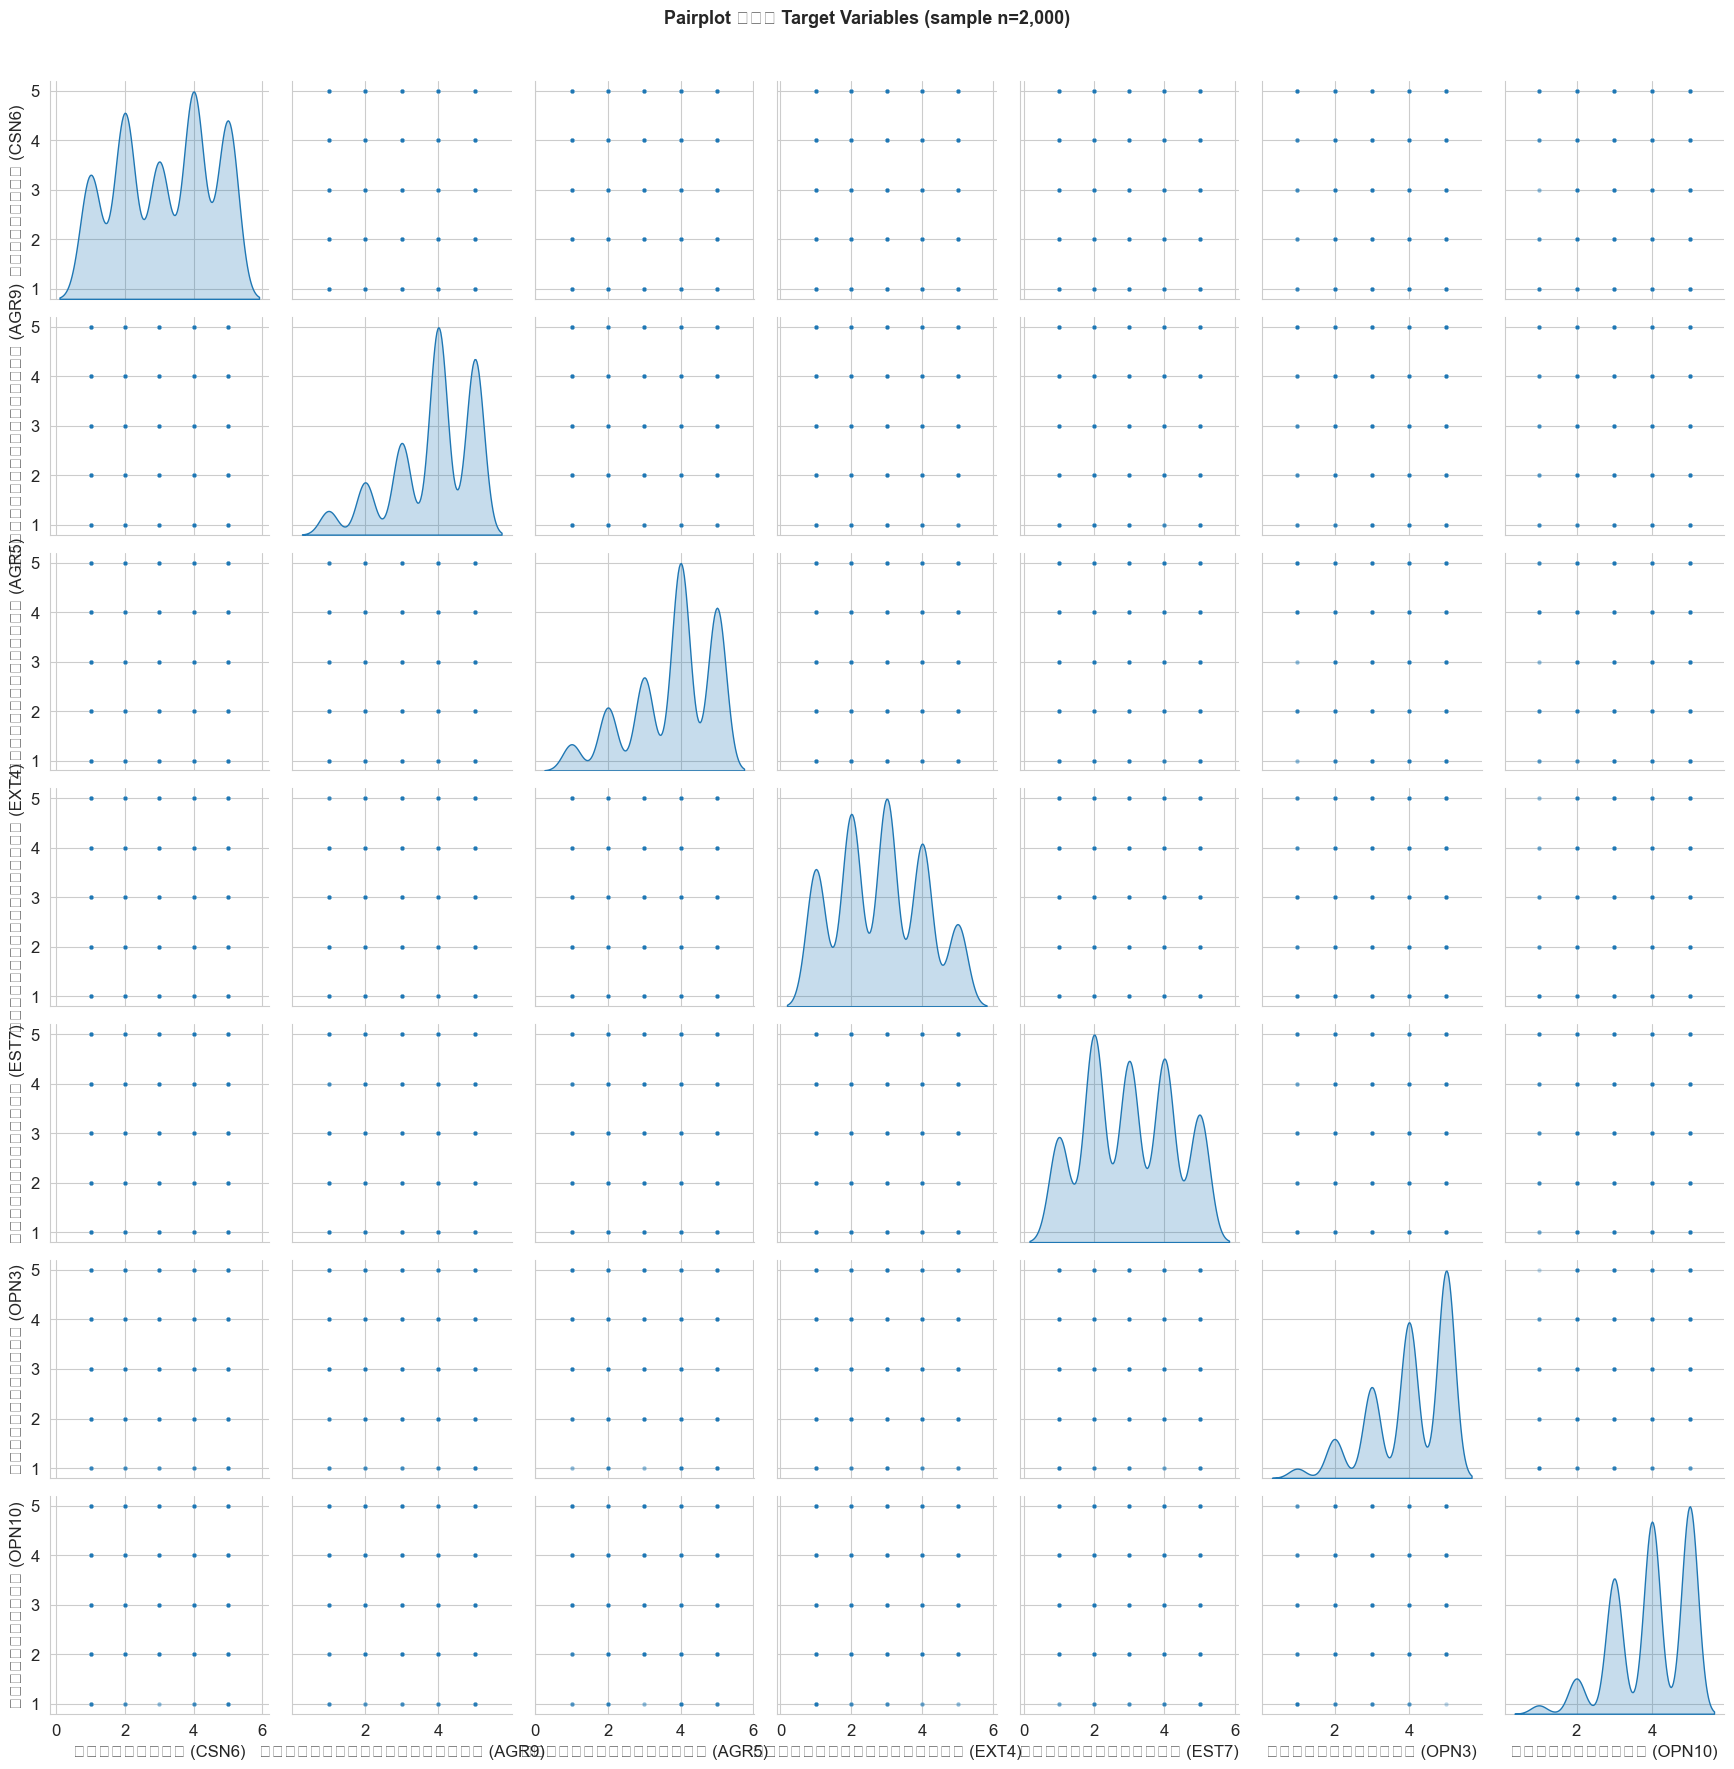

In [13]:
sample_y = y.sample(n=min(2000, len(y)), random_state=42)
sample_y_renamed = sample_y.rename(columns=TARGET_LABELS)

g = sns.pairplot(sample_y_renamed, diag_kind='kde', plot_kws={'alpha': 0.3, 's': 10},
                 diag_kws={'fill': True})
g.fig.suptitle('Pairplot ของ Target Variables (sample n=2,000)', y=1.01, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.6 Boxplot: Target แยกตามค่าสูง/กลาง/ต่ำของ Big Five Score

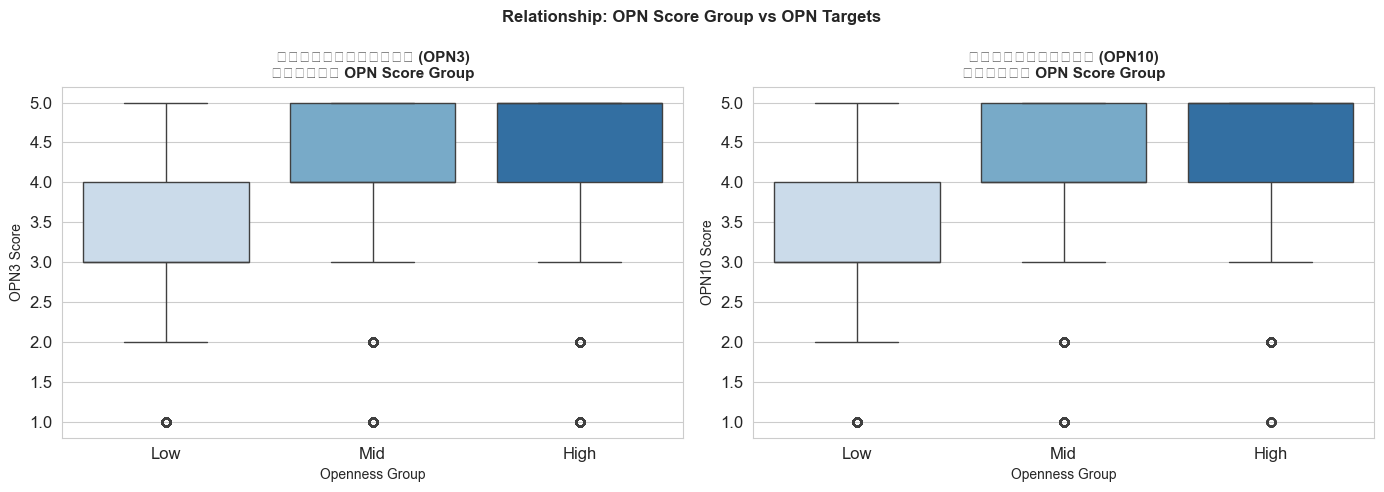

In [14]:
# จัดกลุ่ม OPN_score เป็น 3 ระดับ (Low / Mid / High)
df_plot = df_transformed.copy()
df_plot['OPN_group'] = pd.qcut(df_plot['OPN_score'], q=3, labels=['Low', 'Mid', 'High'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, target in enumerate(['OPN3', 'OPN10']):
    ax = axes[i]
    sns.boxplot(data=df_plot, x='OPN_group', y=target, ax=ax,
                palette='Blues', order=['Low', 'Mid', 'High'])
    ax.set_title(f'{TARGET_LABELS[target]}\nแยกตาม OPN Score Group', fontsize=11, fontweight='bold')
    ax.set_xlabel('Openness Group', fontsize=10)
    ax.set_ylabel(f'{target} Score', fontsize=10)

fig.suptitle('Relationship: OPN Score Group vs OPN Targets', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Model Training with XGBoost

### 4.1 Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train set: X={X_train.shape}, y={y_train.shape}')
print(f'Test  set: X={X_test.shape},  y={y_test.shape}')

Train set: X=(699547, 43), y=(699547, 7)
Test  set: X=(174887, 43),  y=(174887, 7)


### 4.2 Train Individual XGBoost Model ต่อ Target (7 โมเดล)

เราสร้างโมเดล XGBoost แยกสำหรับแต่ละ target เพื่อให้สามารถ tune hyperparameters ได้ต่างกัน และตรวจสอบ feature importance ได้แม่นยำกว่า MultiOutput

In [16]:
# XGBoost Hyperparameters
XGB_PARAMS = dict(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective='reg:squarederror',
    eval_metric='mae',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

models = {}
results = {}

for target in TARGET_COLS:
    print(f'Training XGBoost for: {TARGET_LABELS[target]} ...', end=' ')
    
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_train, y_train[target],
        eval_set=[(X_test, y_test[target])],
        verbose=False
    )
    
    y_pred_train = model.predict(X_train)
    y_pred_test  = model.predict(X_test)
    
    mae_train = mean_absolute_error(y_train[target], y_pred_train)
    mae_test  = mean_absolute_error(y_test[target],  y_pred_test)
    
    models[target] = model
    results[target] = {
        'MAE_train': mae_train,
        'MAE_test':  mae_test,
        'y_pred_test': y_pred_test
    }
    print(f'  Train MAE={mae_train:.4f}  |  Test MAE={mae_test:.4f}')

print('\nAll models trained successfully.')

Training XGBoost for: ลืมวางของ (CSN6) ...   Train MAE=0.8174  |  Test MAE=0.8248
Training XGBoost for: รู้สึกอารมณ์คนอื่น (AGR9) ...   Train MAE=0.5745  |  Test MAE=0.5777
Training XGBoost for: สนใจปัญหาคนอื่น (AGR5) ...   Train MAE=0.6346  |  Test MAE=0.6376
Training XGBoost for: ชอบอยู่ในพื้นหลัง (EXT4) ...   Train MAE=0.6168  |  Test MAE=0.6178
Training XGBoost for: อารมณ์แปรปรวน (EST7) ...   Train MAE=0.5766  |  Test MAE=0.5785
Training XGBoost for: จินตนาการสูง (OPN3) ...   Train MAE=0.5557  |  Test MAE=0.5595
Training XGBoost for: มีไอเดียมาก (OPN10) ...   Train MAE=0.5149  |  Test MAE=0.5176

All models trained successfully.


---
## 5. Model Evaluation

### 5.1 Summary: MAE ทุก Target

In [17]:
eval_df = pd.DataFrame([
    {
        'Target': col,
        'พฤติกรรม': TARGET_LABELS[col],
        'MAE (Train)': results[col]['MAE_train'],
        'MAE (Test)':  results[col]['MAE_test'],
        'Overfit?': '⚠️' if results[col]['MAE_test'] - results[col]['MAE_train'] > 0.15 else '✅'
    }
    for col in TARGET_COLS
])

eval_df['MAE (Train)'] = eval_df['MAE (Train)'].round(4)
eval_df['MAE (Test)']  = eval_df['MAE (Test)'].round(4)
print(eval_df.to_string(index=False))
print(f"\nAverage Test MAE: {eval_df['MAE (Test)'].mean():.4f}")

Target                  พฤติกรรม  MAE (Train)  MAE (Test) Overfit?
  CSN6          ลืมวางของ (CSN6)       0.8174      0.8248        ✅
  AGR9 รู้สึกอารมณ์คนอื่น (AGR9)       0.5745      0.5777        ✅
  AGR5    สนใจปัญหาคนอื่น (AGR5)       0.6346      0.6376        ✅
  EXT4  ชอบอยู่ในพื้นหลัง (EXT4)       0.6168      0.6178        ✅
  EST7      อารมณ์แปรปรวน (EST7)       0.5766      0.5785        ✅
  OPN3       จินตนาการสูง (OPN3)       0.5557      0.5595        ✅
 OPN10       มีไอเดียมาก (OPN10)       0.5149      0.5176        ✅

Average Test MAE: 0.6162


### 5.2 MAE Comparison Chart

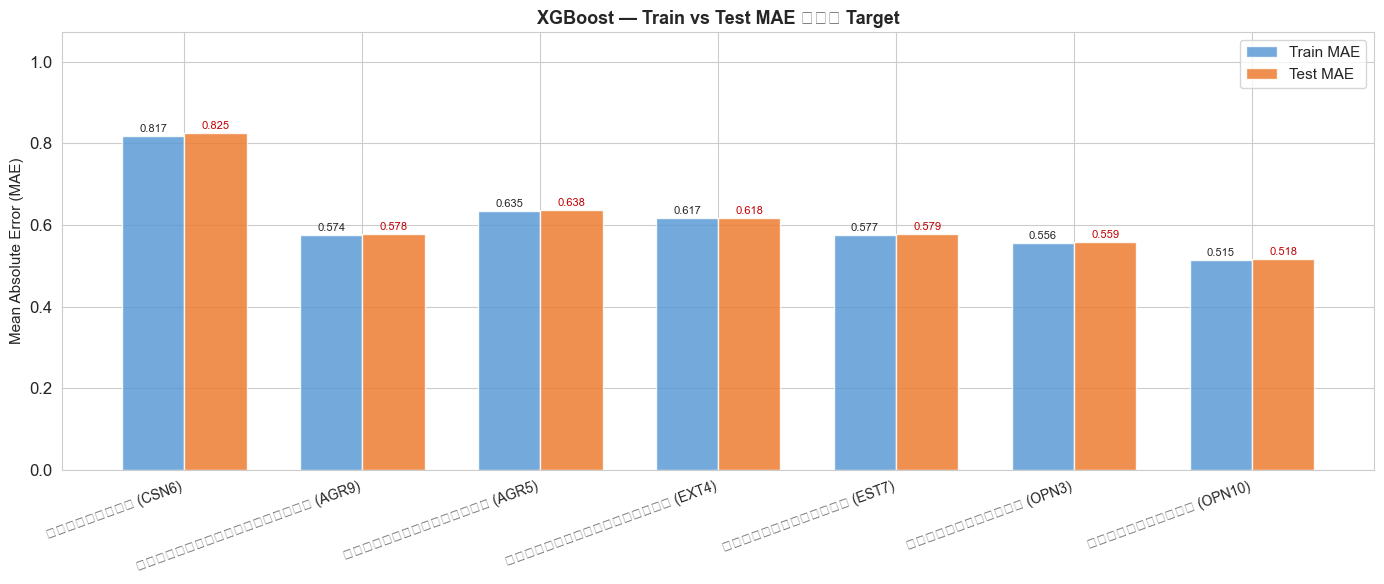

In [18]:
x_labels = [TARGET_LABELS[c] for c in TARGET_COLS]
mae_train_vals = [results[c]['MAE_train'] for c in TARGET_COLS]
mae_test_vals  = [results[c]['MAE_test']  for c in TARGET_COLS]

x = np.arange(len(TARGET_COLS))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars_train = ax.bar(x - width/2, mae_train_vals, width, label='Train MAE', color='#5B9BD5', alpha=0.85)
bars_test  = ax.bar(x + width/2, mae_test_vals,  width, label='Test MAE',  color='#ED7D31', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Mean Absolute Error (MAE)', fontsize=11)
ax.set_title('XGBoost — Train vs Test MAE ต่อ Target', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, max(mae_test_vals) * 1.3)

for bar in bars_train:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars_test:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, color='#C00000')

plt.tight_layout()
plt.show()

### 5.3 Actual vs Predicted Plot

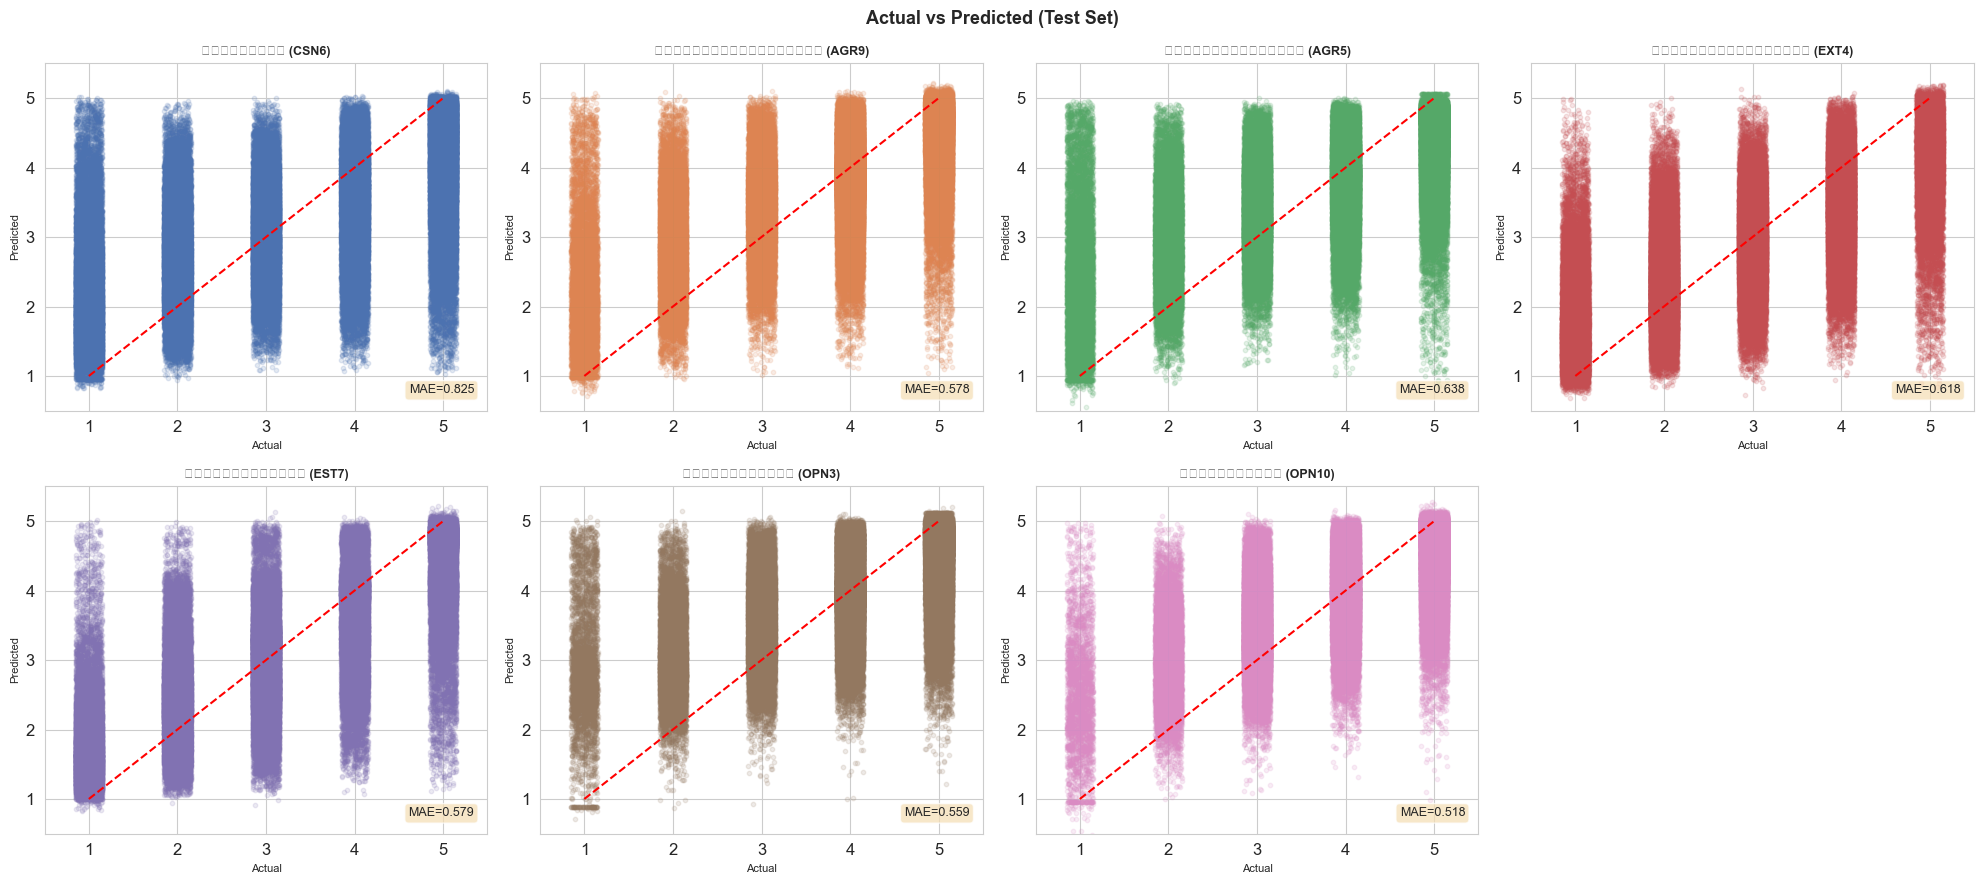

In [19]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    actual = y_test[target].values
    predicted = results[target]['y_pred_test']

    # Jitter เพื่อให้เห็นการกระจาย
    jitter = np.random.uniform(-0.15, 0.15, size=len(actual))
    ax.scatter(actual + jitter, predicted, alpha=0.15, s=10, color=colors[i])
    ax.plot([1, 5], [1, 5], 'r--', linewidth=1.5, label='Perfect prediction')
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(0.5, 5.5)
    ax.set_title(TARGET_LABELS[target], fontsize=9, fontweight='bold')
    ax.set_xlabel('Actual', fontsize=8)
    ax.set_ylabel('Predicted', fontsize=8)
    ax.text(0.97, 0.05, f'MAE={results[target]["MAE_test"]:.3f}',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

axes[-1].set_visible(False)
fig.suptitle('Actual vs Predicted (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Residual Distribution

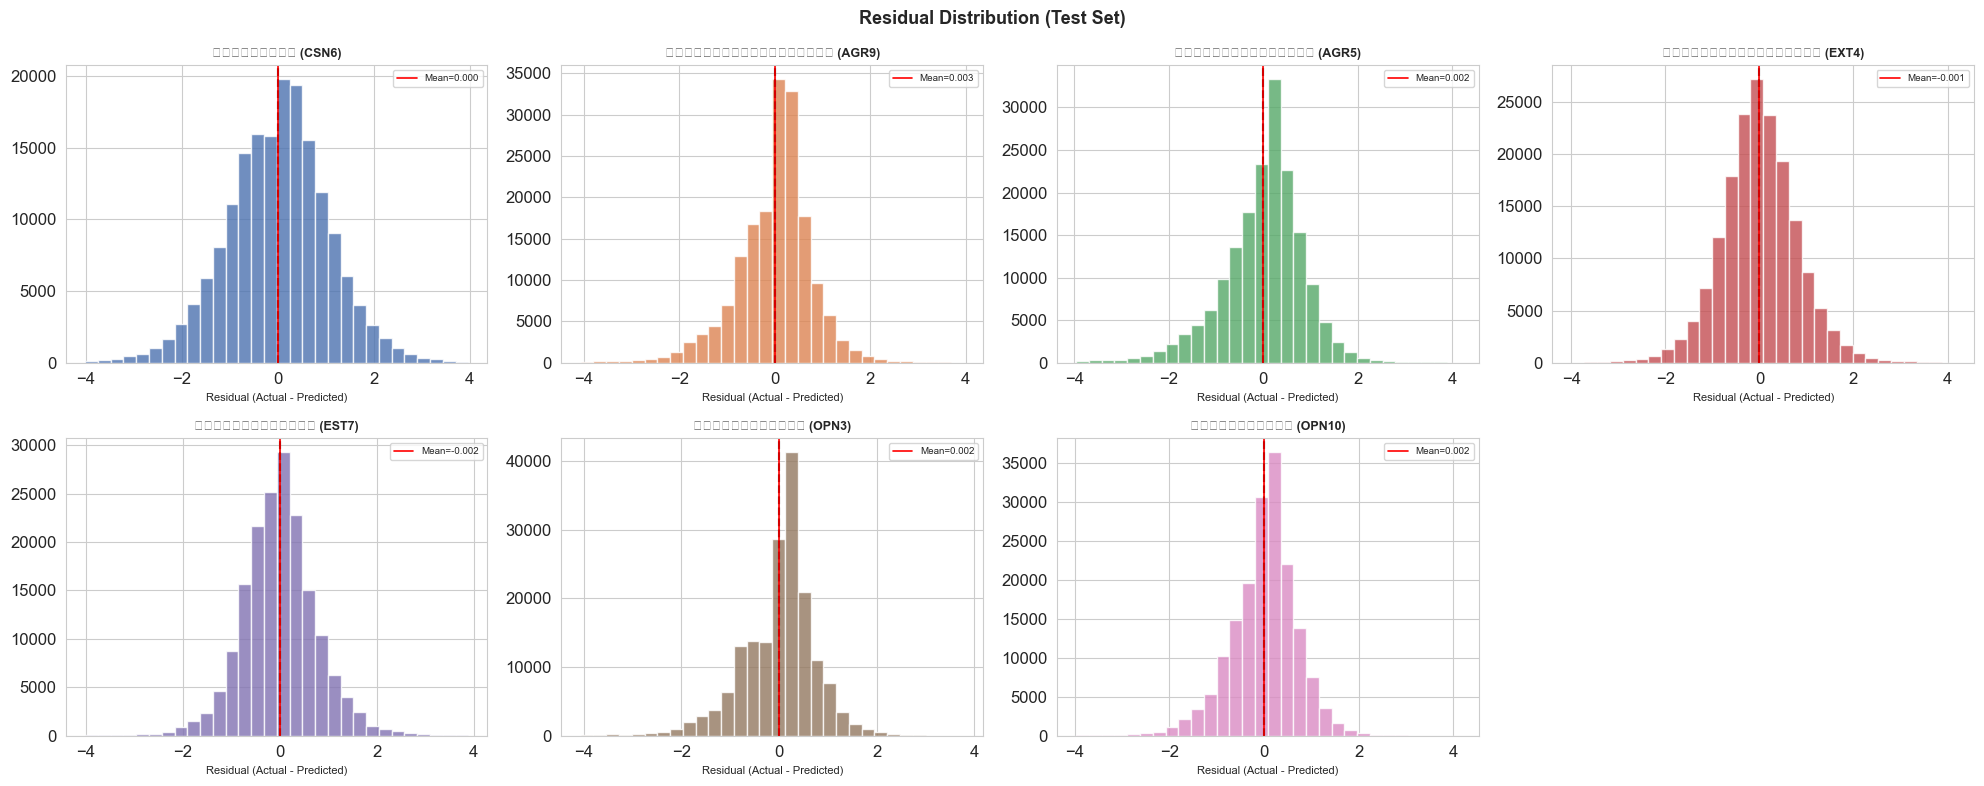

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    residuals = y_test[target].values - results[target]['y_pred_test']
    ax.hist(residuals, bins=30, color=colors[i], alpha=0.8, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1.5)
    ax.axvline(residuals.mean(), color='red', linestyle='-', linewidth=1.2,
               label=f'Mean={residuals.mean():.3f}')
    ax.set_title(TARGET_LABELS[target], fontsize=9, fontweight='bold')
    ax.set_xlabel('Residual (Actual - Predicted)', fontsize=8)
    ax.legend(fontsize=7)

axes[-1].set_visible(False)
fig.suptitle('Residual Distribution (Test Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Feature Importance Analysis

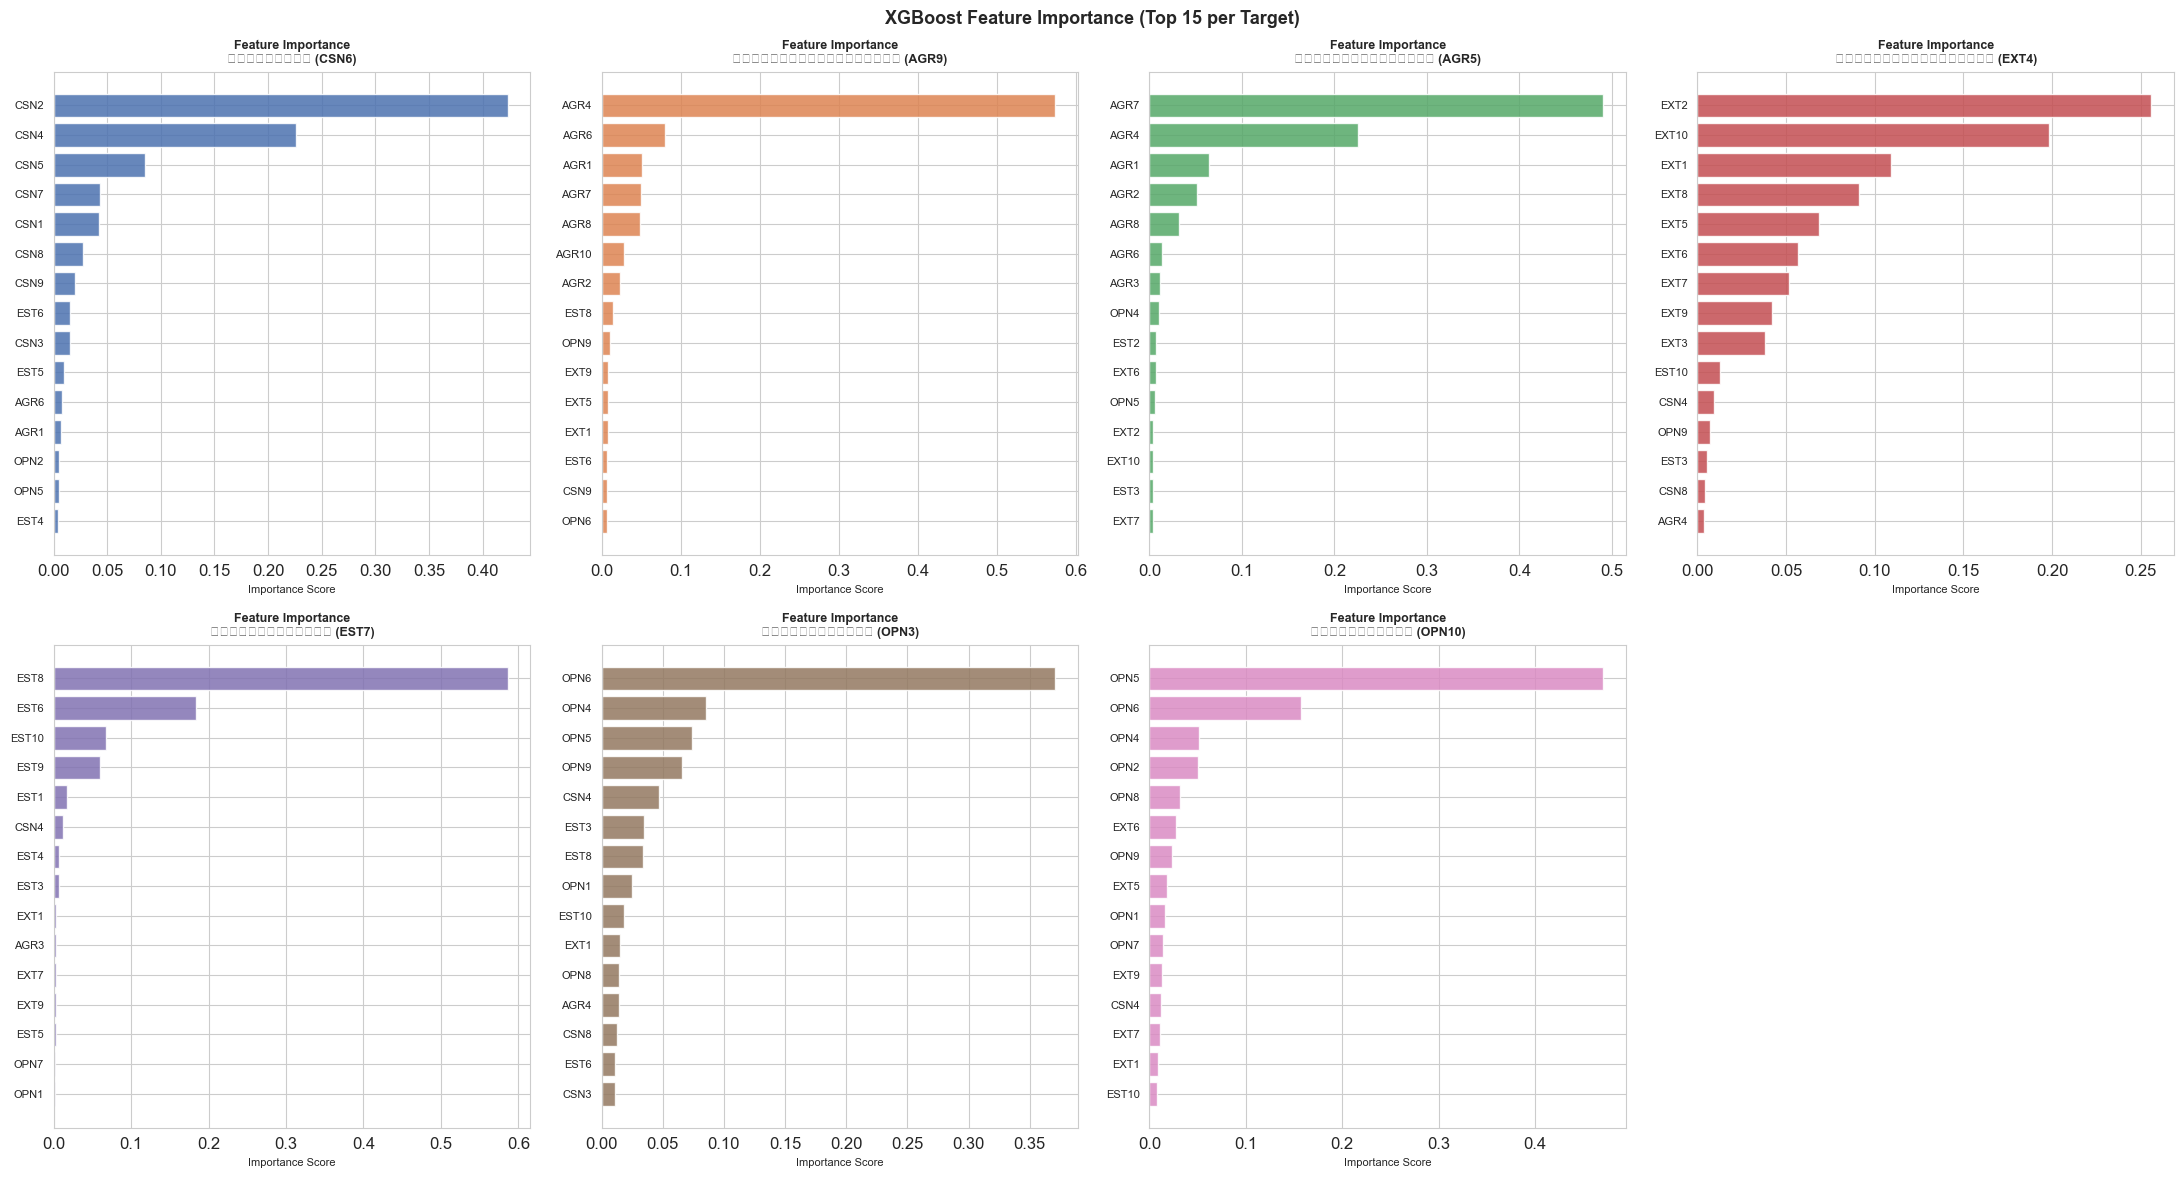

In [21]:
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
axes = axes.flatten()

for i, target in enumerate(TARGET_COLS):
    ax = axes[i]
    model = models[target]
    importance = pd.Series(model.feature_importances_, index=FEATURE_COLS)
    top15 = importance.sort_values(ascending=False).head(15)

    bars = ax.barh(top15.index[::-1], top15.values[::-1], color=colors[i], alpha=0.85)
    ax.set_title(f'Feature Importance\n{TARGET_LABELS[target]}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Importance Score', fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

axes[-1].set_visible(False)
fig.suptitle('XGBoost Feature Importance (Top 15 per Target)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. สรุปผล (Summary)

In [22]:
print('=' * 65)
print('           FINAL MODEL SUMMARY — XGBoost')
print('=' * 65)
print(f'  Total samples used     : {len(X):,}')
print(f'  Train / Test split     : 80% / 20%')
print(f'  Features               : {len(FEATURE_COLS)} columns')
print(f'  Targets (behaviors)    : {len(TARGET_COLS)} columns')
print('-' * 65)
print(f'  {"Target":<30} {"Train MAE":>12} {"Test MAE":>12}')
print('-' * 65)
for col in TARGET_COLS:
    label = TARGET_LABELS[col]
    r = results[col]
    print(f'  {label:<30} {r["MAE_train"]:>12.4f} {r["MAE_test"]:>12.4f}')
print('-' * 65)
avg_test = np.mean([results[c]['MAE_test'] for c in TARGET_COLS])
avg_train = np.mean([results[c]['MAE_train'] for c in TARGET_COLS])
print(f'  {"AVERAGE":<30} {avg_train:>12.4f} {avg_test:>12.4f}')
print('=' * 65)
print(f'\n  Scale: 1–5 → MAE < 0.5 ถือว่าอยู่ในเกณฑ์ดี')
print(f'         MAE ≈ {avg_test:.2f} หมายความว่าโมเดลทำนายผิดพลาดเฉลี่ย {avg_test:.2f} คะแนน')

           FINAL MODEL SUMMARY — XGBoost
  Total samples used     : 874,434
  Train / Test split     : 80% / 20%
  Features               : 43 columns
  Targets (behaviors)    : 7 columns
-----------------------------------------------------------------
  Target                            Train MAE     Test MAE
-----------------------------------------------------------------
  ลืมวางของ (CSN6)                     0.8174       0.8248
  รู้สึกอารมณ์คนอื่น (AGR9)            0.5745       0.5777
  สนใจปัญหาคนอื่น (AGR5)               0.6346       0.6376
  ชอบอยู่ในพื้นหลัง (EXT4)             0.6168       0.6178
  อารมณ์แปรปรวน (EST7)                 0.5766       0.5785
  จินตนาการสูง (OPN3)                  0.5557       0.5595
  มีไอเดียมาก (OPN10)                  0.5149       0.5176
-----------------------------------------------------------------
  AVERAGE                              0.6129       0.6162

  Scale: 1–5 → MAE < 0.5 ถือว่าอยู่ในเกณฑ์ดี
         MAE ≈ 0.62 หมายความว่าโมเดลท

In [24]:
import joblib
import os

os.makedirs("models", exist_ok=True)

for target, model in models.items():
    filename = f"models/xgb_{target}.pkl"
    joblib.dump(model, filename)

print("Saved all models!")

Saved all models!
